In [2]:
import gwosc
import matplotlib.pyplot as plt
import torch
import matplotlib.pyplot as plt
import numpy as np
import plotfancy as pf
from scipy.signal.windows import tukey

import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries
from gwosc.datasets import event_gps

pf.housestyle_rcparams()

True

In [3]:
event_time = event_gps('GW150914')
detector = 'H1'
psd_window = 100
start = event_time - 500
end = event_time + 500
data = TimeSeries.fetch_open_data(detector, start, end, sample_rate=4096, verbose=True)

Fetched 1 URLs from gwosc.org for [1126258962 .. 1126259963))
Reading data... [Done]


True

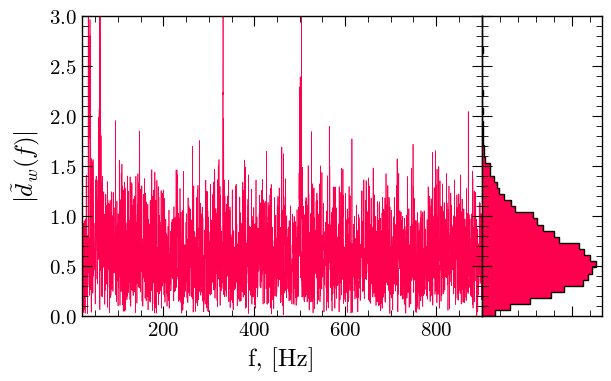

In [4]:
fig, ax = pf.create_plot()
ax2 = fig.add_axes((1,0,0.3,1), sharey=ax)
plt.setp(ax2.get_yticklabels(), visible=False)
plt.setp(ax2.get_xticklabels(), visible=False)


chunk_d = 4
psd = data.psd(fftlength=chunk_d)

# noise_start = data.t0.value+1
# noise_td = data.crop(noise_start, noise_start+chunk_d)
noise_td = data.crop(event_time-chunk_d/2, event_time+chunk_d/2)

tukey_alpha = 0.5/chunk_d
window = tukey(len(noise_td), alpha=tukey_alpha)
noise_td_windowed = noise_td*window

noise_fd = noise_td_windowed.fft()
noise_fd_w = np.abs(noise_fd/np.sqrt(psd))

ax.plot(noise_fd_w.frequencies,noise_fd_w, color='#ff004f', lw=0.5)
ax2.hist(noise_fd_w, orientation='horizontal', density=True, bins=np.linspace(0,3,50), histtype='step', color='black')
ax2.hist(noise_fd_w, orientation='horizontal', density=True, bins=np.linspace(0,3,50), color='#ff004f')

ax.set_xlim([20,900])
ax.set_ylim([0,3])
ax.set_xlabel('f, [Hz]')
ax.set_ylabel(r'$|\tilde{d}_w(f)|$')


pf.fix_plot([ax,ax2])




In [10]:
np.array(data.data)

array([-8.43618070e-19, -8.53576701e-19, -8.53299930e-19, ...,
       -1.85256862e-19, -2.01578299e-19, -2.11931601e-19],
      shape=(4096000,))

In [11]:
noise_td.shape

(16384,)

In [14]:
psd.data